In [69]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import joblib


In [70]:
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)


PROJECT_DIR: C:\Users\LENOVO\diabetes_project
DATA_DIR: C:\Users\LENOVO\diabetes_project\data
MODELS_DIR: C:\Users\LENOVO\diabetes_project\models


In [73]:
clean_path = os.path.join(DATA_DIR, "diabetes_cleaned4.csv")
raw_path   = os.path.join(DATA_DIR, "diabetes_dataset.csv")

data_path = clean_path if os.path.exists(clean_path) else raw_path
print("Using dataset:", data_path)

df = pd.read_csv(data_path, keep_default_na=False)
df1 = pd.read_csv(raw_path, keep_default_na=False)

df.columns = df.columns.str.strip().str.replace(" ", "_")
print("✅ Loaded:", df.shape)
df.head()


Using dataset: C:\Users\LENOVO\diabetes_project\data\diabetes_cleaned4.csv
✅ Loaded: (10000, 11)


,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes
0,58,Female,White,35.8,83.4,123.9,Moderate,1538,Moderate,Never,0
1,48,Male,Asian,24.1,71.4,183.7,Moderate,2653,Moderate,Current,0
2,34,Female,Black,25.0,113.8,142.0,Low,1684,Heavy,Former,1
3,62,Male,Asian,32.7,100.4,167.4,Low,3796,Moderate,Never,1
4,27,Female,Asian,33.5,110.8,146.4,Moderate,3161,Heavy,Current,0


In [74]:
target_col = "Diabetes"
fbg_col = "Fasting_Blood_Glucose"
lab_col = "HbA1c"

if target_col not in df.columns:
    if fbg_col not in df.columns:
        raise ValueError("❌ 'Diabetes' target not found and 'Fasting_Blood_Glucose' not found to create it.")

    # Convert to numeric safely
    df[fbg_col] = pd.to_numeric(df[fbg_col], errors="coerce")
    df1[lab_col] = pd.to_numeric(df1[lab_col], errors="coerce")

    df[target_col] = np.where(
        (df[fbg_col] >= 126) | (df1[lab_col] >= 6.5),
        1,
        0
    )

    print("✅ Created Diabetes target using Fasting_Blood_Glucose ≥ 126 OR HbA1c ≥ 6.5")

df[target_col].value_counts()


✅ Created Diabetes target using Fasting_Blood_Glucose ≥ 126 OR HbA1c ≥ 6.5


Diabetes
1    9047
0     953
Name: count, dtype: int64

In [75]:
X = df.drop(columns=["Diabetes","Fasting_Blood_Glucose"])
y = df[target_col].astype(int)

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

print("\nClass distribution:")
print(y.value_counts())
print("\nClass distribution (%):")
print((y.value_counts(normalize=True)*100).round(2))


Numeric: ['Age', 'BMI', 'Waist_Circumference', 'Dietary_Intake_Calories', 'Family_History_of_Diabetes']
Categorical: ['Sex', 'Ethnicity', 'Physical_Activity_Level', 'Alcohol_Consumption', 'Smoking_Status']

Class distribution:
Diabetes
1    9047
0     953
Name: count, dtype: int64

Class distribution (%):
Diabetes
1    90.47
0     9.53
Name: proportion, dtype: float64


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (8000, 10) Test: (2000, 10)


In [77]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("✅ Preprocessor ready")


✅ Preprocessor ready


In [78]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier()
}

pipelines = {name: Pipeline([("preprocess", preprocessor), ("model", clf)])
             for name, clf in models.items()}


In [79]:
def evaluate(pipe, X_test, y_test, threshold=0.5):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }


In [80]:
baseline_results = []
trained_baselines = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    trained_baselines[name] = pipe
    
    metrics = evaluate(pipe, X_test, y_test)
    metrics["Model"] = name
    baseline_results.append(metrics)

baseline_df = pd.DataFrame(baseline_results).sort_values("ROC-AUC", ascending=False)
baseline_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Model
1,0.9045,0.904500,1.000000,0.949856,0.530529,Random Forest
3,0.8975,0.904234,0.991708,0.945953,0.505146,KNN
0,0.5135,0.900383,0.519624,0.658955,0.498740,Logistic Regression
2,0.9045,0.904500,1.000000,0.949856,0.494216,SVM


In [81]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_spaces = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 500, 800],
        "model__max_depth": [None, 5, 10, 15, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None]
    },
    "SVM": {
        "model__C": [0.1, 1, 10, 50],
        "model__gamma": ["scale", "auto"],
        "model__kernel": ["rbf"]
    },
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 50]
    }
}

tuned_models = {}
tuned_results = []

for model_name, params in param_spaces.items():
    print(f"\n🔧 Tuning {model_name} ...")
    search = RandomizedSearchCV(
        pipelines[model_name],
        param_distributions=params,
        n_iter=20,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    search.fit(X_train, y_train)
    
    best_pipe = search.best_estimator_
    tuned_models[model_name] = best_pipe
    
    test_metrics = evaluate(best_pipe, X_test, y_test)
    test_metrics["Model"] = model_name + " (Tuned)"
    tuned_results.append(test_metrics)

    print("✅ Best params:", search.best_params_)
    print("✅ Best CV ROC-AUC:", search.best_score_)

tuned_df = pd.DataFrame(tuned_results).sort_values("ROC-AUC", ascending=False)
tuned_df



🔧 Tuning Random Forest ...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best params: {'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
✅ Best CV ROC-AUC: 0.5144058917862783

🔧 Tuning SVM ...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\LENOVO\diabetes_project\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


✅ Best params: {'model__kernel': 'rbf', 'model__gamma': 'scale', 'model__C': 50}
✅ Best CV ROC-AUC: 0.5230979460561953

🔧 Tuning Logistic Regression ...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


C:\Users\LENOVO\diabetes_project\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 5 is smaller than n_iter=20. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


✅ Best params: {'model__C': 50}
✅ Best CV ROC-AUC: 0.506597590558037


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Model
0,0.9045,0.904500,1.000000,0.949856,0.518854,Random Forest (Tuned)
1,0.9045,0.904500,1.000000,0.949856,0.510997,SVM (Tuned)
2,0.5135,0.900383,0.519624,0.658955,0.498728,Logistic Regression (Tuned)


In [82]:
all_results_df = pd.concat([baseline_df, tuned_df], ignore_index=True)
all_results_df = all_results_df.sort_values("ROC-AUC", ascending=False)
all_results_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Model
0,0.9045,0.904500,1.000000,0.949856,0.530529,Random Forest
4,0.9045,0.904500,1.000000,0.949856,0.518854,Random Forest (Tuned)
5,0.9045,0.904500,1.000000,0.949856,0.510997,SVM (Tuned)
1,0.8975,0.904234,0.991708,0.945953,0.505146,KNN
2,0.5135,0.900383,0.519624,0.658955,0.498740,Logistic Regression
6,0.5135,0.900383,0.519624,0.658955,0.498728,Logistic Regression (Tuned)
3,0.9045,0.904500,1.000000,0.949856,0.494216,SVM


In [83]:
best_row = all_results_df.iloc[0]
best_name = best_row["Model"]

print("✅ Best model:", best_name)

if "(Tuned)" in best_name:
    base_name = best_name.replace(" (Tuned)", "")
    best_pipe = tuned_models[base_name]
else:
    best_pipe = trained_baselines[best_name]

y_prob = best_pipe.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
j = tpr - fpr
best_idx = np.argmax(j)
best_threshold = float(thresholds[best_idx])

print("✅ Best threshold:", best_threshold)


✅ Best model: Random Forest
✅ Best threshold: 0.89


In [84]:
final_metrics = evaluate(best_pipe, X_test, y_test, threshold=best_threshold)
final_metrics


{'Accuracy': 0.6695,
 'Precision': 0.9111747851002865,
 'Recall': 0.703150912106136,
 'F1-Score': 0.7937597503900156,
 'ROC-AUC': 0.5305294354290213}

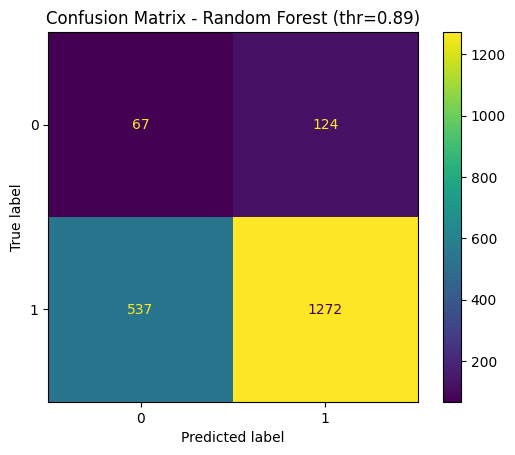

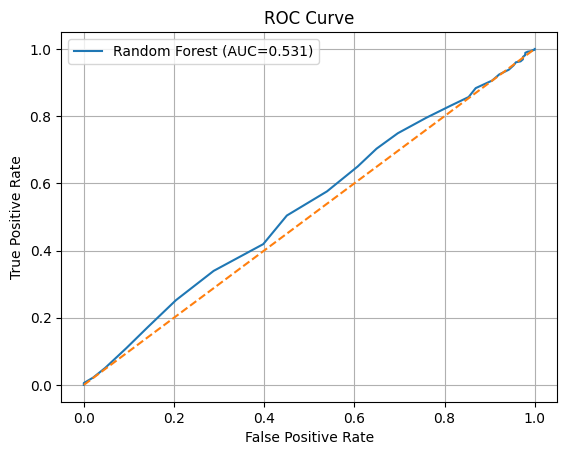

In [85]:
y_pred = (y_prob >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_name} (thr={best_threshold:.2f})")
plt.show()

plt.figure()
plt.plot(fpr, tpr, label=f"{best_name} (AUC={roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [86]:
PIPE_PATH = os.path.join(MODELS_DIR, "diabetes_risk_pipeline.pkl")
THR_PATH  = os.path.join(MODELS_DIR, "best_threshold.pkl")
RES_PATH  = os.path.join(DATA_DIR, "model_comparison_results.csv")

joblib.dump(best_pipe, PIPE_PATH)
joblib.dump(best_threshold, THR_PATH)
all_results_df.to_csv(RES_PATH, index=False)

print("✅ Saved:")
print("Pipeline:", PIPE_PATH)
print("Threshold:", THR_PATH)
print("Results:", RES_PATH)


✅ Saved:
Pipeline: C:\Users\LENOVO\diabetes_project\models\diabetes_risk_pipeline.pkl
Threshold: C:\Users\LENOVO\diabetes_project\models\best_threshold.pkl
Results: C:\Users\LENOVO\diabetes_project\data\model_comparison_results.csv


In [87]:
loaded_pipe = joblib.load(os.path.join(MODELS_DIR, "diabetes_risk_pipeline.pkl"))
loaded_thr  = joblib.load(os.path.join(MODELS_DIR, "best_threshold.pkl"))

p = loaded_pipe.predict_proba(X_test.iloc[[0]])[0, 1]
pred = int(p >= loaded_thr)

print("✅ Sanity check OK")
print("Prob:", p)
print("Pred:", pred)
print("Thr:", loaded_thr)


✅ Sanity check OK
Prob: 0.91
Pred: 1
Thr: 0.89
